# EpiCoV EDA for 2021

- Number of sequences: `50,000`
- Collection date range: 1 Jan 2021 to 9 Jan 2021
- Submission date range: 6 Jan 2021 to 19 Jun 2025

In [1]:
# General
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Custom helpers
from utils import (standardize_country_name, get_continent, choropleth_continent,
choropleth_world, map_age_to_group, col_fillna, plot_dominant_choropleth)

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "~/gcs-buckets"
YEAR = "2021"
PLOTS_PATH = "epicov2021_plots/2021_50k_collection/"

In [3]:
%%time
FILEPATH = os.path.join(DATA_PATH, "1Jan21_9Jan21_collected.csv")
params = {"filepath_or_buffer":FILEPATH, "sep": "," if FILEPATH.endswith(".csv") else "\t"}
df = pd.read_csv(**params)
df.sort_values(by=["Collection date"], inplace=True)
num_rows = 50000
if df.shape[0] > num_rows:
    print(f"Limiting dataset to first {num_rows} rows for testing.")
    df = df.iloc[:num_rows, :]
df.shape, df.info()

Limiting dataset to first 50000 rows for testing.
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 6901 to 47294
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Accession ID                     50000 non-null  object
 1   Submission date                  50000 non-null  object
 2   Virus name                       50000 non-null  object
 3   Collection date                  50000 non-null  object
 4   Location                         50000 non-null  object
 5   Host                             50000 non-null  object
 6   Additional location information  1656 non-null   object
 7   Sampling strategy                6689 non-null   object
 8   Gender                           50000 non-null  object
 9   Patient age                      49999 non-null  object
 10  Patient status                   50000 non-null  object
 11  Last vaccinated                  85 non-null 

((50000, 18), None)

In [4]:
df["Submission date"] = pd.to_datetime(df["Submission date"], format="mixed")
df["Submission date"].min(), df["Submission date"].max()

(Timestamp('2021-01-06 00:00:00'), Timestamp('2025-06-19 00:00:00'))

In [5]:
df["submission_yr"] = df["Submission date"].dt.strftime("%Y")
df["submission_yr"].value_counts().sort_index()

submission_yr
2021    45283
2022     3811
2023      690
2024      172
2025       44
Name: count, dtype: int64

In [6]:
df["Collection date"] = pd.to_datetime(df["Collection date"], format="mixed")
df["Collection date"].min(), df["Collection date"].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2021-01-09 00:00:00'))

In [7]:
df["collection_yr"] = df["Collection date"].dt.strftime("%Y")
df["collection_yr"].value_counts().sort_index()

collection_yr
2021    50000
Name: count, dtype: int64

Let us validate if `Submission_date` is after the `Collection_date`

In [8]:
df[df["Collection date"] > df["Submission date"]].shape

(0, 20)

Find average time between collection of sample and submission of sequence collected on or after Jan 2020

In [9]:
df = df[df["Collection date"] >= pd.to_datetime("2020-01-01")]
df["collection_to_submission_days"] = (df["Submission date"] - df["Collection date"]).dt.days
df["collection_to_submission_days"].describe()

count    50000.000000
mean       128.048480
std        186.707675
min          3.000000
25%         20.000000
50%         51.000000
75%        155.000000
max       1630.000000
Name: collection_to_submission_days, dtype: float64

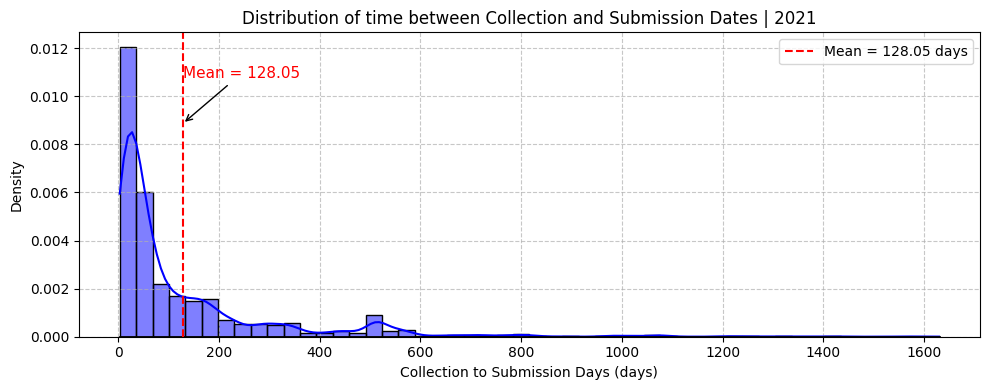

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df["collection_to_submission_days"], bins=50, kde=True, color='blue', stat='density')
sns.lineplot(x=sorted(df["collection_to_submission_days"]), 
             y=np.full(df.shape[0], 0), color='black', linewidth=2)
mean_days = df["collection_to_submission_days"].mean()
plt.axvline(mean_days, color='red', linestyle='--', label=f"Mean = {mean_days:.2f} days")

# Place annotation above the mean line, at the top of the plot
ymax = plt.gca().get_ylim()[1]
plt.annotate(f"Mean = {mean_days:.2f}", xy=(mean_days, ymax*0.7), xytext=(mean_days+0.5, ymax*0.85),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=11)

plt.xlabel("Collection to Submission Days (days)")
plt.title(f"Distribution of time between Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_to_submission_days_distribution_{YEAR}.png"), dpi=300)
plt.show()

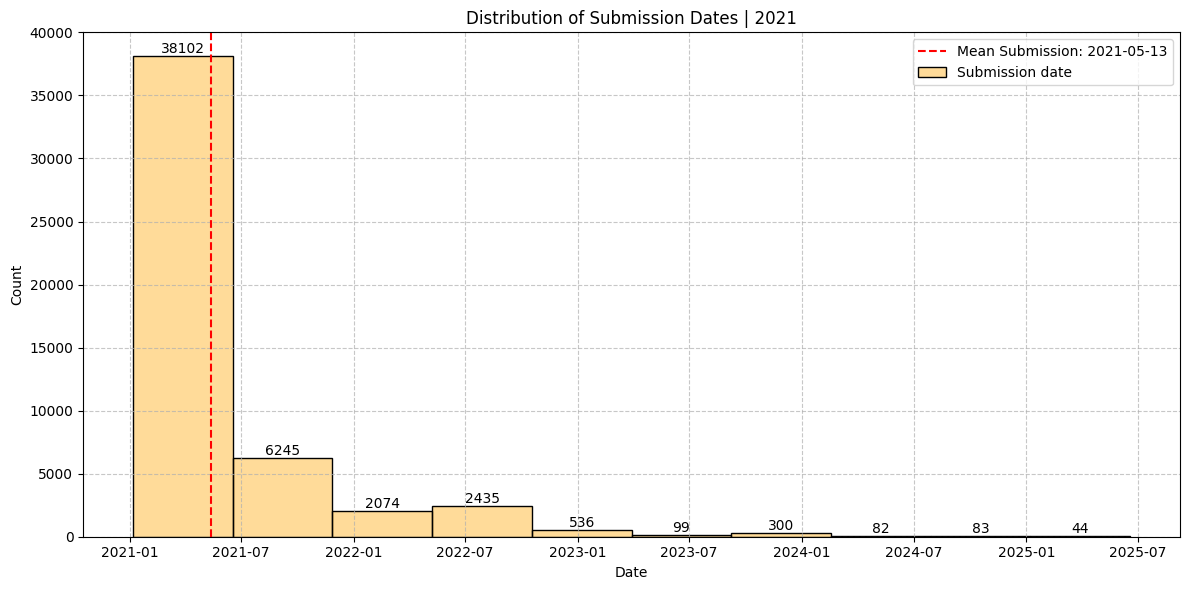

In [11]:
plt.figure(figsize=(12, 6))

# Plot histograms for submission dates
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.4)

# Calculate means
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"submission_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

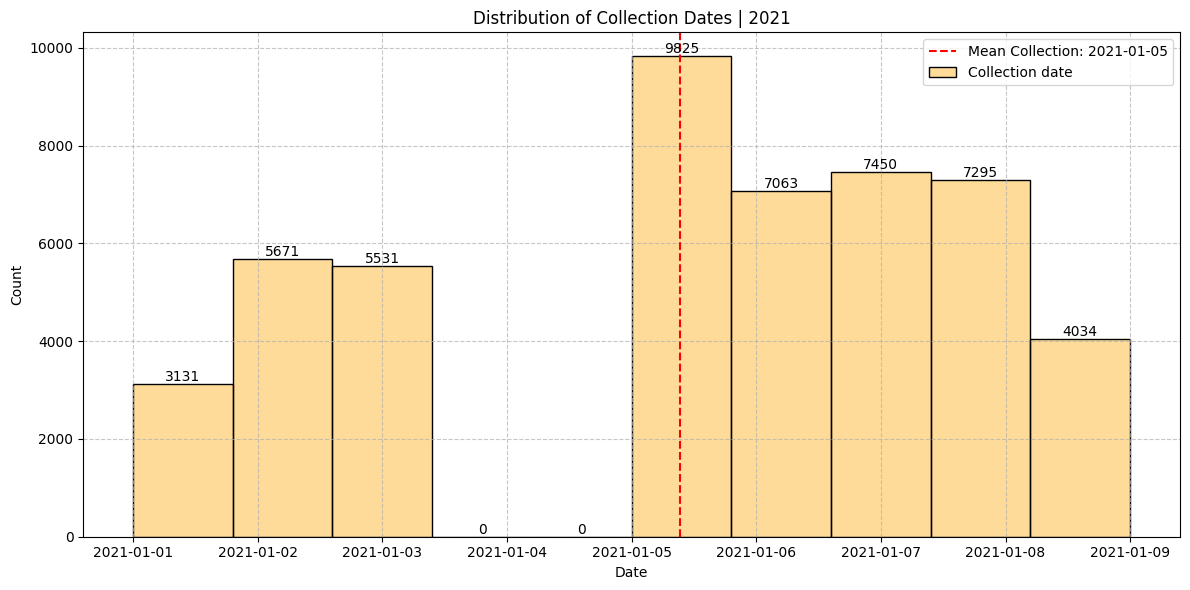

In [12]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection dates
sns.histplot(df["Collection date"], bins=10, color="orange", label="Collection date", kde=False, alpha=0.4)

# Calculate means
mean_collection = df["Collection date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="red", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

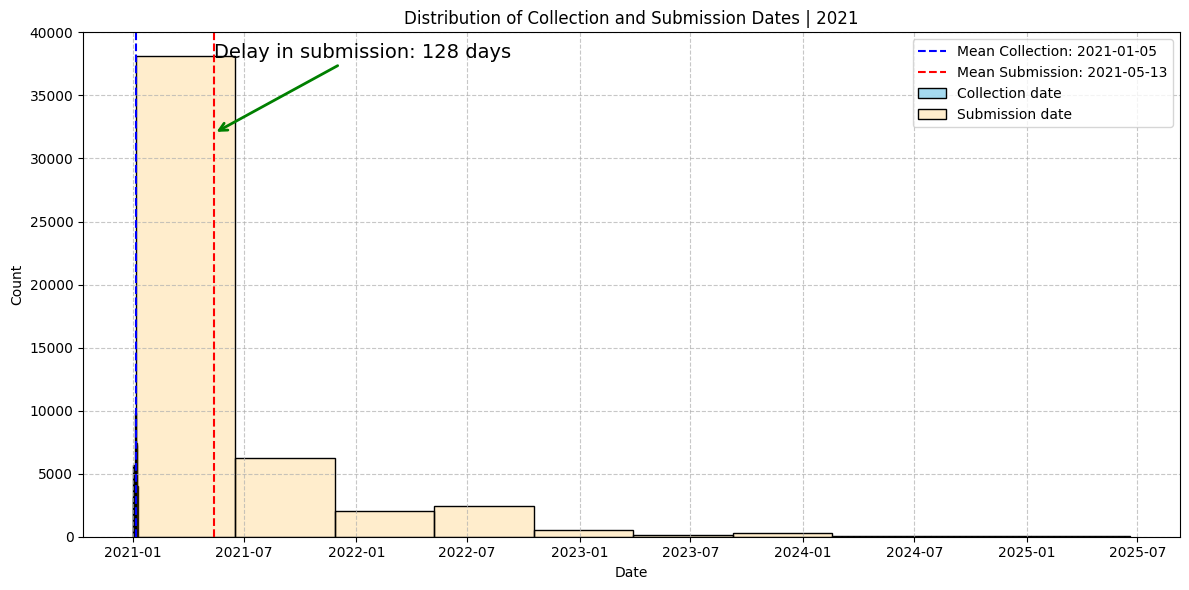

In [13]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection and submission dates
sns.histplot(df["Collection date"], bins=10, color="skyblue", label="Collection date", kde=False)
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.2)

# Calculate means
mean_collection = df["Collection date"].mean()
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="blue", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate lead time
lead_time = (mean_submission - mean_collection).days
plt.annotate(
    f"Delay in submission: {lead_time} days",
    xy=(mean_submission, plt.ylim()[1]*0.8),
    xytext=(mean_submission, plt.ylim()[1]*0.95),
    arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2),
    color="black",
    fontsize=14,
    ha='left'
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_submission_dates_distribution_{YEAR}.png"), dpi=300)
plt.show()

In [14]:
df["Gender"].value_counts()

Gender
unknown    33372
Female      8972
Male        7606
49.0           4
41.0           3
70.0           2
39.0           2
55.0           2
32.0           2
21.0           2
44.0           2
40.0           1
47.0           1
36.0           1
29             1
24.0           1
51.0           1
22.0           1
64.0           1
35.0           1
30.0           1
63.0           1
59.0           1
38.0           1
42.0           1
23.0           1
37             1
82.0           1
77.0           1
57             1
26.0           1
50.0           1
71.0           1
60.0           1
76.0           1
54.0           1
53.0           1
31.0           1
48.0           1
18.0           1
27.0           1
28.0           1
Name: count, dtype: int64

In [15]:
df["Patient status"].value_counts()

Patient status
unknown                            47126
Live                                 887
Hospitalized                         258
Recovered                            250
Released                             206
                                   ...  
Hospitalized, no clinical signs        1
Contact surveillance                   1
Live.                                  1
Mild Sympthoms                         1
Suspect-SAD                            1
Name: count, Length: 63, dtype: int64

In [16]:
df["Patient age"].value_counts()

Patient age
unknown        33619
27               363
26               332
29               319
24               319
               ...  
14 months          1
16-19              1
52,4 months        1
27.0               1
25.0               1
Name: count, Length: 268, dtype: int64

In [17]:
df[~df["Gender"].isin(["Male", "Female", "unknown"])]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,submission_yr,collection_yr,collection_to_submission_days
6686,EPI_ISL_4405243,2021-09-22,hCoV-19/Argentina/PAIS-A0870/2021,2021-01-01,South America / Argentina / Buenos Aires / Tigre,Human,NaN,NaN,36.0,Female,...,NaN,Original,NaN,NaN,N.5,GR,"(Spike_Q414R,N_R203K,NSP12_K91R,Spike_T778I,N_...",2021,2021,264
2690,EPI_ISL_4405387,2021-09-22,hCoV-19/Argentina/PAIS-A0920/2021,2021-01-01,South America / Argentina / Buenos Aires / Lom...,Human,NaN,NaN,41.0,Female,...,NaN,Original,NaN,NaN,N.5,GR,"(Spike_Q414R,N_R203K,N_G204R,NSP3_L1035F,NSP12...",2021,2021,264
8306,EPI_ISL_12835639,2022-05-20,hCoV-19/USA/LA-FUS0035A6/2021,2021-01-02,North America / USA / Louisiana / New Orleans,Human,NaN,NaN,70.0,Male,...,NaN,Original,NaN,NaN,B.1.596,GH,"(NS3_A54V,NSP2_R380H,N_P67S,NS3_Q57H,NSP2_T85I...",2022,2021,503
4073,EPI_ISL_2686350,2021-06-25,hCoV-19/Burkina Faso/M_LBC_3412/2021,2021-01-02,Africa / Burkina Faso / Bobo Dioulasso,Human,NaN,NaN,47.0,Male,...,NaN,Original,Nasopharyngeal swab,NaN,B.1.1.404,GR,"(NSP3_R352C,N_R203K,NSP15_D310Y,N_G204R,NS3_T2...",2021,2021,174
4072,EPI_ISL_2686351,2021-06-25,hCoV-19/Burkina Faso/M_LBC_3421/2021,2021-01-02,Africa / Burkina Faso / Bobo Dioulasso,Human,NaN,NaN,40.0,Female,...,NaN,Original,Nasopharyngeal swab,NaN,B.1.1.404,GR,"(N_R203K,NS3_V77F,NSP15_D310Y,N_G204R,Spike_G2...",2021,2021,174
4071,EPI_ISL_2686352,2021-06-25,hCoV-19/Burkina Faso/M_LBC_3434/2021,2021-01-02,Africa / Burkina Faso / Bobo Dioulasso,Human,NaN,NaN,41.0,Male,...,NaN,Original,Nasopharyngeal swab,NaN,B.1,GH,"(NSP6_M52I,NS8_E19K,NSP14_I15V,N_Q70R,NS3_S216...",2021,2021,174
4070,EPI_ISL_2686353,2021-06-25,hCoV-19/Burkina Faso/M_LBC_3447/2021,2021-01-02,Africa / Burkina Faso / Bobo Dioulasso,Human,NaN,NaN,21.0,Female,...,NaN,Original,Nasopharyngeal swab,NaN,B.1,GH,"(NSP6_M52I,N_Q70R,NS3_T14I,N_P13T,NSP16_G265C,...",2021,2021,174
2689,EPI_ISL_7406428,2021-12-09,hCoV-19/Argentina/PAIS-A1134/2021,2021-01-02,South America / Argentina / San Luis / Juan Ma...,Human,NaN,Baseline surveillance,29,unknown,...,NaN,Original,Nasopharyngeal swab,NaN,N.5,GR,"(NSP1_M85del,Spike_Q414R,NSP14_P412S,NSP1_V86d...",2021,2021,341
20886,EPI_ISL_4405314,2021-09-22,hCoV-19/Argentina/PAIS-A0895/2021,2021-01-05,South America / Argentina / Buenos Aires / Azul,Human,NaN,NaN,22.0,Male,...,NaN,Original,NaN,NaN,B.1.499,GH,"(NSP7_S25L,NSP3_P1103T,Spike_E654Q,NSP2_E201G,...",2021,2021,260
23512,EPI_ISL_17050046,2023-02-28,hCoV-19/Brazil/SP-IMT-CD2230/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,51.0,unknown,...,NaN,Original,NaN,NaN,B.1.1.28,GR,"(NS7a_I10M,Spike_N679K,NS3_H78Y,N_P6H,N_R203K,...",2023,2021,784


So, there are cases where Patient age is mentioned in the gender column and vice versa. So we swap these first. There are also cases where the patient gender is mentioned in the Sampling strategy column. Let's fix that next.

In [18]:
# Swap the two values in these rows (Patient age and Patent gender)
for i, row in df[~df["Gender"].isin(["Male", "Female", "unknown"])].iterrows():
    age = row["Patient age"]
    df.at[i, "Patient age"] = row["Gender"]
    df.at[i, "Gender"] = age

In [19]:
df[df["Sampling strategy"].isin(["Male", "Female"])]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,submission_yr,collection_yr,collection_to_submission_days
5104,EPI_ISL_1111156,2021-03-01,hCoV-19/Peru/HUA-INS-696/2021,2021-01-02,South America / Peru / Huanuco,Human,NaN,Female,unknown,unknown,...,NaN,Original,NaN,NaN,B.1.1.1,GR,"(NSP5_G15S,N_R203K,NSP3_T428I,N_D402Y,N_G204R,...",2021,2021,58
5103,EPI_ISL_1111157,2021-03-01,hCoV-19/Peru/HUA-INS-697/2021,2021-01-02,South America / Peru / Huanuco,Human,NaN,Male,unknown,unknown,...,NaN,Original,NaN,NaN,B.1.1.1,GR,"(NSP1_T78I,Spike_S477N,NSP5_G15S,N_R203K,NSP3_...",2021,2021,58
23512,EPI_ISL_17050046,2023-02-28,hCoV-19/Brazil/SP-IMT-CD2230/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,unknown,51.0,...,NaN,Original,NaN,NaN,B.1.1.28,GR,"(NS7a_I10M,Spike_N679K,NS3_H78Y,N_P6H,N_R203K,...",2023,2021,784
23513,EPI_ISL_17050045,2023-02-28,hCoV-19/Brazil/SP-IMT-CD2222/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,unknown,49.0,...,NaN,Original,NaN,NaN,B.1.1.28,GR,"(NSP3_A1800V,NSP3_M1547V,N_R203K,NSP3_D455Y,N_...",2023,2021,784
23514,EPI_ISL_17050044,2023-02-28,hCoV-19/Brazil/SP-IMT-CD2221/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,unknown,23.0,...,NaN,Original,NaN,NaN,B.1.1.28,GR,"(Spike_L249del,Spike_Y248del,Spike_T716I,N_R20...",2023,2021,784
23515,EPI_ISL_17050041,2023-02-28,hCoV-19/Brazil/SP-IMT-CD2209/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,unknown,24.0,...,NaN,Original,NaN,NaN,P.7,GR,"(NSP6_Q208H,NS3_D27Y,N_T362I,N_R203K,NSP3_P146...",2023,2021,784
23517,EPI_ISL_17050032,2023-02-28,hCoV-19/Brazil/SP-IMT-CD2182/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,unknown,38.0,...,NaN,Original,NaN,NaN,B.1.1.28,GR,"(Spike_M153T,N_R203K,NS3_G224V,N_G204R,NSP7_L7...",2023,2021,784
23516,EPI_ISL_17050033,2023-02-28,hCoV-19/Brazil/SP-IMT-CD2183/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Male,unknown,42.0,...,NaN,Original,NaN,NaN,B.1.1.28,GR,"(Spike_M153T,NSP7_M3I,N_R203K,NS3_G224V,NSP12_...",2023,2021,784
23940,EPI_ISL_17050522,2023-02-28,hCoV-19/Brazil/SP-IMT-SCP35/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,unknown,49.0,...,NaN,Original,NaN,NaN,P.1,GR,"(Spike_R190S,NSP6_S106del,Spike_H655Y,Spike_E4...",2023,2021,784
23941,EPI_ISL_17050521,2023-02-28,hCoV-19/Brazil/SP-IMT-SCP33/2021,2021-01-05,South America / Brazil / Sao Paulo / Sao Caeta...,Human,NaN,Female,unknown,64.0,...,NaN,Original,NaN,NaN,P.1.14,GR,"(Spike_R190S,NSP4_S184N,NSP6_S106del,Spike_H65...",2023,2021,784


In [20]:
# Swap the two values in these rows (Patient gender and Sampling strategy)
for i, row in df[df["Sampling strategy"].isin({"Male", "Female"})].iterrows():
    df.at[i, "Gender"], df.at[i, "Sampling strategy"] = df.at[i, "Sampling strategy"], df.at[i, "Gender"]

In [21]:
df[df["Sampling strategy"].isin({"Male", "Female"})]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,submission_yr,collection_yr,collection_to_submission_days


In [22]:
df["Gender"].value_counts()

Gender
unknown    33354
Female      9009
Male        7637
Name: count, dtype: int64

## Geographical distribution

Let's see the geographical distribution of various parameters

In [23]:
(print(set([x.split("/")[0] for x in df["Location"].values.tolist()])), df.nunique())

{'Africa ', 'Oceania ', 'Asia ', 'Europe ', 'South America ', 'North America '}


(None,
 Accession ID                       50000
 Submission date                      580
 Virus name                         49995
 Collection date                        8
 Location                            1822
 Host                                   1
 Additional location information      503
 Sampling strategy                     62
 Gender                                 3
 Patient age                          272
 Patient status                        63
 Last vaccinated                       19
 Passage                               20
 Specimen                             111
 Additional host information           72
 Lineage                              649
 Clade                                 10
 AA Substitutions                   32278
 submission_yr                          5
 collection_yr                          1
 collection_to_submission_days        831
 dtype: int64)

Collate required columns

In [24]:
df1 = df[["Accession ID", "Location", "Gender", "Patient age", "Patient status"]].reset_index(drop=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Location        50000 non-null  object
 2   Gender          50000 non-null  object
 3   Patient age     49999 non-null  object
 4   Patient status  50000 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


Split location into `continent`, `country`, `state` and `city`

In [25]:
df1["continent"], df1["country"], df1["state"], df1["city"] = np.nan, np.nan, np.nan, np.nan

cols = ["continent", "country", "state", "city"]
for i, row in tqdm(df1.iterrows(), desc="Geographical information extraction", total=df1.shape[0]):
    loc = row["Location"]
    locs = [x.strip() for x in loc.split("/")]
    for j in range(min(len(locs),len(cols))):
        df1.loc[i, cols[j]] = locs[j]
df1.drop(columns=["Location"], inplace=True)
df1.info()

Geographical information extraction:   0%|          | 0/50000 [00:00<?, ?it/s]

Geographical information extraction: 100%|██████████| 50000/50000 [01:31<00:00, 545.81it/s]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Gender          50000 non-null  object
 2   Patient age     49999 non-null  object
 3   Patient status  50000 non-null  object
 4   continent       50000 non-null  object
 5   country         50000 non-null  object
 6   state           46741 non-null  object
 7   city            14820 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


## Entries distribution countrywise

We look at number of entries from each country normalised by:
- country's population
- country's per capita income
- reported cases
- reported deaths

First let's create a dictionary containing country's metadata

In [26]:
df1["country"].nunique()

151

Countrywise population from [Our World in Data](https://ourworldindata.org/population-growth)

In [27]:
df_pop = pd.read_csv(os.path.join(DATA_PATH, "our_world_in_data_population.csv"))
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 75 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   country  256 non-null    object
 1   1950     256 non-null    int64 
 2   1951     256 non-null    int64 
 3   1952     256 non-null    int64 
 4   1953     256 non-null    int64 
 5   1954     256 non-null    int64 
 6   1955     256 non-null    int64 
 7   1956     256 non-null    int64 
 8   1957     256 non-null    int64 
 9   1958     256 non-null    int64 
 10  1959     256 non-null    int64 
 11  1960     256 non-null    int64 
 12  1961     256 non-null    int64 
 13  1962     256 non-null    int64 
 14  1963     256 non-null    int64 
 15  1964     256 non-null    int64 
 16  1965     256 non-null    int64 
 17  1966     256 non-null    int64 
 18  1967     256 non-null    int64 
 19  1968     256 non-null    int64 
 20  1969     256 non-null    int64 
 21  1970     256 non-null    int64 
 22  19

In [28]:
(len(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist())),
 set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))

(6,
 {'Cabo Verde',
  'Canary Islands',
  'Czech Republic',
  'Republic of the Congo',
  'Timor-Leste',
  'USA'})

In [29]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)]["country"].value_counts()

country
USA                      18769
Czech Republic             256
Canary Islands             143
Republic of the Congo       16
Cabo Verde                  11
Timor-Leste                 11
Name: count, dtype: int64

A few countries like South Korea, Czech Republic etc have different alternative names used in the dataframes. Let us standardize it using the following snippet. Also, Population of Canary Islands is part of that of Spain - included Canary as part of Spain

In [30]:
df1["country"] = df1["country"].str.replace("USA", "United States")
df1["country"] = df1["country"].str.replace("Republic of the Congo", "Congo")
df1["country"] = df1["country"].str.replace("Timor-Leste", "East Timor")
df1["country"] = df1["country"].str.replace("Cabo Verde", "Cape Verde")
df1["country"] = df1["country"].str.replace("Canary Islands", "Spain")

In [31]:
df_pop["country"] = df_pop["country"].str.replace("Czechia", "Czech Republic")

In [32]:
countries = df1["country"].unique()
country_meta = [{"country":x} for x in countries]
len(country_meta), country_meta[:3]

(150,
 [{'country': 'United States'}, {'country': 'Uganda'}, {'country': 'India'}])

In [33]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)].shape[0], df1[df1["country"].isin(focus)]["country"].value_counts()

(0, Series([], Name: count, dtype: int64))

In [34]:
# Fill in population data in country_meta
for x in tqdm(country_meta, desc="Filling population data"):
    country = x["country"]
    cont = df1[df1["country"]==country]["continent"].values[0]
    x["continent"] = cont
    if country in df_pop["country"].values.tolist():
        pop = df_pop[df_pop["country"]==country][YEAR].values[0]
        x["population"] = int(pop)
country_meta[:3]

Filling population data:   0%|          | 0/150 [00:00<?, ?it/s]

Filling population data: 100%|██████████| 150/150 [00:02<00:00, 50.32it/s]


[{'country': 'United States',
  'continent': 'North America',
  'population': 340161392},
 {'country': 'Uganda', 'continent': 'Africa', 'population': 45910886},
 {'country': 'India', 'continent': 'Asia', 'population': 1414203840}]

Collect only entries where population is non-zero => exclude Crimea as of now

In [35]:
skip_countries = ["Canary Islands", "Crimea"]
df2 = df1[~df1["country"].isin(skip_countries)]
df1.shape, df2.shape

((50000, 8), (50000, 8))

In [36]:
df2.to_csv(os.path.join(DATA_PATH, f"{YEAR}_cleaned.csv"), index=False)

### A. Normalising by country's population
#### A.1. Number of entries from each country

Let's first see how many entries are from different countries grouped by their continent

In [37]:
df_country = pd.DataFrame([x for x in country_meta if x["country"] not in ["Canary Islands","Crimea"]])
df_country.shape, df_country[df_country["population"].isnull()].shape

((150, 3), (0, 3))

In [38]:
sorted(df_pop["country"].unique().tolist())

['Afghanistan',
 'Africa (UN)',
 'Albania',
 'Algeria',
 'American Samoa',
 'Americas (UN)',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Asia (UN)',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',

In [39]:
exclude = ["Africa (UN)", "Asia (UN)", "Americas (UN)", "Europe (UN)",
            "Oceania (UN)", "World", "High-income countries", "Land-locked developing countries (LLDC)",
            "Latin America and the Caribbean (UN)", "Least developed countries", "Less developed regions",
            "Less developed regions, excluding China", "Less developed regions, excluding least developed countries",
            "Low-income countries", "Lower-middle-income countries", "More developed regions", "Northern America (UN)",
            "Small island developing states (SIDS)", "Upper-middle-income countries"]
df_pop = df_pop[~df_pop["country"].isin(exclude)]
df_pop["country"].nunique()

237

In [40]:
df_merged = pd.merge(df_country, df_pop[["country", YEAR]], on="country", how="right")
df_merged.rename(columns={YEAR: f"population_{YEAR}"}, inplace=True)
df_merged.drop(columns=["population"], inplace=True)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          237 non-null    object
 1   continent        150 non-null    object
 2   population_2021  237 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.7+ KB


In [41]:
df_merged["country_standard"] = df_merged["country"].apply(standardize_country_name)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         150 non-null    object
 2   population_2021   237 non-null    int64 
 3   country_standard  237 non-null    object
dtypes: int64(1), object(3)
memory usage: 7.5+ KB


In [42]:
df_merged["continent_x"] = df_merged["country_standard"].apply(get_continent)
df_merged["continent_x"].nunique(), df_merged["continent"].nunique()

(7, 6)

In [43]:
df_merged[df_merged["continent_x"]=="Unknown"]

,country,continent,population_2021,country_standard,continent_x
30,Brunei,NaN,451676,Brunei,Unknown
54,Democratic Republic of Congo,NaN,99148879,Democratic Republic of Congo,Unknown
59,East Timor,Asia,1350102,East Timor,Unknown
111,Kosovo,Europe,1741407,Kosovo,Unknown
136,Micronesia (country),NaN,111589,Micronesia (country),Unknown
162,Palestine,Asia,5185289,Palestine,Unknown
174,Russia,Europe,145836117,Russia,Unknown
177,Saint Helena,NaN,5378,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,41546,Sint Maarten (Dutch part),Unknown
216,Turkey,Europe,86686206,Turkey,Unknown


In [44]:
for i, row in df_merged.iterrows():
    if row["continent_x"] == "Unknown" and not pd.isnull(row["continent"]):
        df_merged.at[i, "continent_x"] = row["continent"]
    
    if pd.isnull(row["continent"]) and row["continent_x"] != "Unknown":
        df_merged.at[i, "continent"] = row["continent_x"]

In [45]:
df_merged["continent"].unique(), df_merged["continent_x"].unique()

(array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', nan], dtype=object),
 array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', 'Unknown'], dtype=object))

In [46]:
df_merged[df_merged["continent"].isna()]

,country,continent,population_2021,country_standard,continent_x
30,Brunei,NaN,451676,Brunei,Unknown
54,Democratic Republic of Congo,NaN,99148879,Democratic Republic of Congo,Unknown
136,Micronesia (country),NaN,111589,Micronesia (country),Unknown
177,Saint Helena,NaN,5378,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,41546,Sint Maarten (Dutch part),Unknown
225,United States Virgin Islands,NaN,87184,United States Virgin Islands,Unknown
229,Vatican,NaN,515,Vatican,Unknown
233,Western Sahara,NaN,558577,Western Sahara,Unknown


In [47]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 13: Azerbaijan - Europe vs Asia
Mismatch at index 51: Curacao - South America vs North America
Mismatch at index 52: Cyprus - Europe vs Asia


We do the following assignment (based on Google search):

- `Azerbaijan` mostly in Western Asia. So we assign `Asia`
- `Curacao` is in `South America`
- `Cyprus` is in `Europe`

In [48]:
df_merged.loc[int(df_merged.index[df_merged["country"]=="Azerbaijan"][0]), "continent"] = "Asia"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Curacao"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Cyprus"][0]), "continent_x"] = "Europe"

In [49]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         229 non-null    object
 2   population_2021   237 non-null    int64 
 3   country_standard  237 non-null    object
 4   continent_x       237 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.4+ KB


9 of the 237 entries have `Unknown` continent. Let's see which countries are these.

In [50]:
df_merged[df_merged["continent_x"] == "Unknown"]

,country,continent,population_2021,country_standard,continent_x
30,Brunei,NaN,451676,Brunei,Unknown
54,Democratic Republic of Congo,NaN,99148879,Democratic Republic of Congo,Unknown
136,Micronesia (country),NaN,111589,Micronesia (country),Unknown
177,Saint Helena,NaN,5378,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,41546,Sint Maarten (Dutch part),Unknown
225,United States Virgin Islands,NaN,87184,United States Virgin Islands,Unknown
229,Vatican,NaN,515,Vatican,Unknown
233,Western Sahara,NaN,558577,Western Sahara,Unknown


Let's ignore these regions for now.

In [51]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

In [52]:
df_merged = df_merged[df_merged["continent_x"] != "Unknown"].drop(columns=["continent_x"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           229 non-null    object
 1   continent         229 non-null    object
 2   population_2021   229 non-null    int64 
 3   country_standard  229 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.9+ KB


In [53]:
# Insert a new row for Antarctica into df_merged
antarctica_row = {
    "country": "Antarctica",
    "continent": "Antarctica",
    f"population_{YEAR}": 0,
    "country_standard": "Antarctica",
}
df_merged = pd.concat([df_merged, pd.DataFrame([antarctica_row])], ignore_index=True)
df_merged.tail()

,country,continent,population_2021,country_standard
225,Wallis and Futuna,Oceania,11544,Wallis and Futuna
226,Yemen,Asia,37140180,Yemen
227,Zambia,Africa,19603556,Zambia
228,Zimbabwe,Africa,15797165,Zimbabwe
229,Antarctica,Antarctica,0,Antarctica


In [54]:
df_merged["num_entries"] = float("NaN")

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        df_merged.loc[i, "num_entries"] = df2[df2["country"]==country].shape[0]
df_merged["num_entries"].describe()

count      150.000000
mean       333.333333
std       1869.593968
min          1.000000
25%          5.000000
50%         17.000000
75%         85.750000
max      18769.000000
Name: num_entries, dtype: float64

Now, we normalize the number of entries by the population of the country to get the comparison to be in a level playing field

In [55]:
# per lakh population
df_merged["num_entries_per_lakh"] = df_merged["num_entries"] / (df_merged[f"population_{YEAR}"] / 1e5)
df_merged.head()

,country,continent,population_2021,country_standard,num_entries,num_entries_per_lakh
0,Afghanistan,Asia,40000360,Afghanistan,NaN,NaN
1,Albania,Europe,2849591,Albania,3.0,0.105278
2,Algeria,Africa,44761051,Algeria,4.0,0.008936
3,American Samoa,Oceania,49202,American Samoa,NaN,NaN
4,Andorra,Europe,78328,Andorra,NaN,NaN


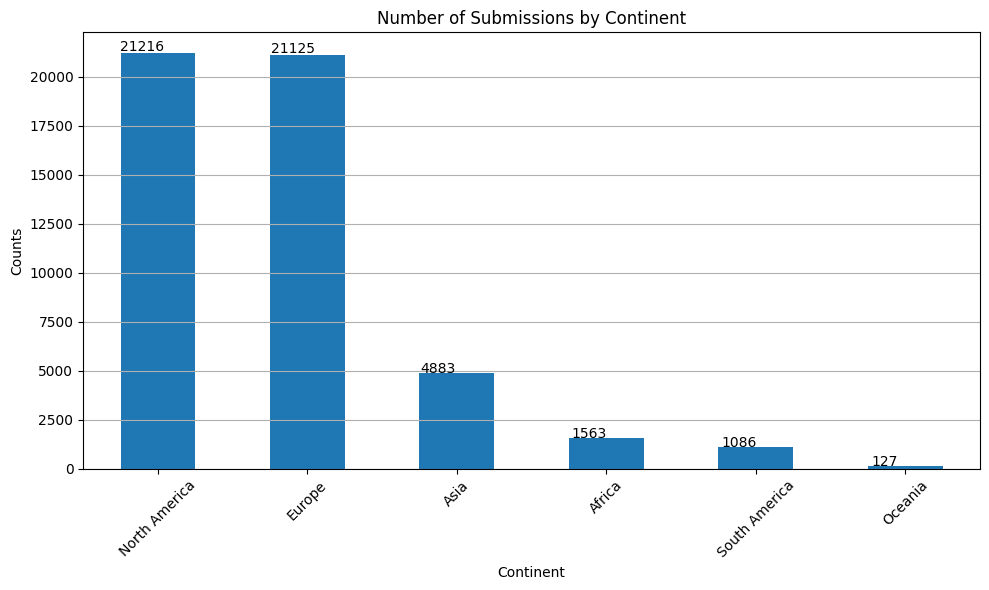

In [56]:
# Plot the bar chart
ax = df2["continent"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title('Number of Submissions by Continent')
plt.grid(axis= 'x')
plt.tight_layout()
plt.show()

In [57]:
df_merged["log_num_entries_per_lakh"] = np.log10(df_merged["num_entries_per_lakh"].replace(0, np.nan))
df_merged["log_num_entries_per_lakh"].describe()

count    150.000000
mean      -0.539086
std        0.958494
min       -3.040309
25%       -1.163098
50%       -0.578121
75%        0.159084
max        2.233210
Name: log_num_entries_per_lakh, dtype: float64

In [58]:
sign = -1 if df_merged["log_num_entries_per_lakh"].min() < 0 else 1
df_merged["log_num_entries_per_lakh"] = df_merged["log_num_entries_per_lakh"] + (df_merged["log_num_entries_per_lakh"].min() * sign)
df_merged["log_num_entries_per_lakh"].describe()

count    150.000000
mean       2.501223
std        0.958494
min        0.000000
25%        1.877211
50%        2.462188
75%        3.199394
max        5.273519
Name: log_num_entries_per_lakh, dtype: float64

In [59]:
# Fill NaN values with a sentinel value (e.g., 0) for visualization purposes
df_merged = col_fillna(df_merged, "log_num_entries_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_world(df_merged,
                        value_column='log_num_entries_per_lakh',
                        color_scale=custom_scale,
                        title=f'Submissions per Lakh Population (World) | Log 10 Scale | {YEAR}',
                        label='Submissions/Lakh (Log 10)',
                        hover_data={
                            f'population_{YEAR}': True,
                            'num_entries': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Plot per‐continent maps

In [60]:
# Define custom color scale including a gray value for the sentinel
custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_continent(df_merged,
                           value_column='log_num_entries_per_lakh',
                           color_scale=custom_scale,
                           title=f'Submissions per 1 Lakh Population by Continent | Log 10 Scale | {YEAR}',
                           label='Submissions/Lakh (Log 10)',
                           YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

#### A.2. Sex distribution across countries

Let's next look at the sex distribution across countries again grouped by continents. We look at sex rather than gender since it is determined at birth and standardized in definitions.

In [61]:
df_merged["sex_m_per_lakh"], df_merged["sex_f_per_lakh"], df_merged["sex_u_per_lakh"] = float('nan'), float('nan'), float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "sex_m_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Male")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "sex_f_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Female")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "sex_u_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "unknown")].shape[0])/(row[f"population_{YEAR}"] / 1e5)

Convert to log 10 scale to show variation

In [62]:
df_merged["log_sex_m_per_lakh"] = np.log10(df_merged["sex_m_per_lakh"].replace(0, np.nan))
df_merged["log_sex_m_per_lakh"].describe()

count    114.000000
mean      -1.003317
std        0.862805
min       -3.376101
25%       -1.520377
50%       -1.083732
75%       -0.544065
max        1.910990
Name: log_sex_m_per_lakh, dtype: float64

In [63]:
sign = -1 if df_merged["log_sex_m_per_lakh"].min() < 0 else 1
df_merged["log_sex_m_per_lakh"] = df_merged["log_sex_m_per_lakh"] + (df_merged["log_sex_m_per_lakh"].min() * sign)
df_merged["log_sex_m_per_lakh"].describe()

count    114.000000
mean       2.372784
std        0.862805
min        0.000000
25%        1.855725
50%        2.292369
75%        2.832036
max        5.287092
Name: log_sex_m_per_lakh, dtype: float64

For choropleth maps, its better to have 3 different maps one for each sex. First we look at a zoomed out view of the whole world

In [64]:
# World map - distribution of males
df_merged = col_fillna(df_merged, "log_sex_m_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
male_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#cbdbfc"],  # very light blue
    [0.01, "#c6dbef"],
    [0.03, "#b3d1e6"],
    [0.06, "#9ecae1"],
    [0.12, "#6bb8d6"],
    [0.25, "#3182bd"],
    [0.5, "#08519c"],
    [1.0, "#08306b"]      # darkest blue
]


fig = choropleth_world(df_merged,
                       value_column="log_sex_m_per_lakh",
                       color_scale=male_scale,
                       title=f"Number of submissions from Males per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Males/1 lakh (Log 10)",
                       hover_data={
                            'sex_m_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we do for the entries submitted by females

In [65]:
df_merged["log_sex_f_per_lakh"] = np.log10(df_merged["sex_f_per_lakh"].replace(0, np.nan))
df_merged["log_sex_f_per_lakh"].describe()

count    111.000000
mean      -0.928700
std        0.926347
min       -3.309155
25%       -1.528662
50%       -0.966724
75%       -0.451500
max        1.952383
Name: log_sex_f_per_lakh, dtype: float64

In [66]:
sign = -1 if df_merged["log_sex_f_per_lakh"].min() < 0 else 1
df_merged["log_sex_f_per_lakh"] = df_merged["log_sex_f_per_lakh"] + (df_merged["log_sex_f_per_lakh"].min() * sign)
df_merged["log_sex_f_per_lakh"].describe()

count    111.000000
mean       2.380455
std        0.926347
min        0.000000
25%        1.780493
50%        2.342430
75%        2.857655
max        5.261538
Name: log_sex_f_per_lakh, dtype: float64

In [67]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_sex_f_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
female_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#ffb2d5"],  # very light pink
    [0.01, "#ffafcb"],
    [0.05, "#fa9fb5"],
    [0.1, "#f768a1"],
    [0.2, "#c51b8a"],
    [0.4, "#ae017e"],
    [1.0, "#7a0177"]   # darkest pink
]

fig = choropleth_world(df_merged,
                       value_column="log_sex_f_per_lakh",
                       color_scale=female_scale,
                       title=f"Number of submissions from Females per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Females/1 lakh (Log 10)",
                       hover_data={
                            'sex_f_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [68]:
df_merged["log_sex_u_per_lakh"] = np.log10(df_merged["sex_u_per_lakh"].replace(0, np.nan))
df_merged["log_sex_u_per_lakh"].describe()

count    82.000000
mean     -0.807794
std       1.064344
min      -3.224426
25%      -1.542986
50%      -0.764827
75%      -0.025894
max       1.287762
Name: log_sex_u_per_lakh, dtype: float64

In [69]:
sign = -1 if df_merged["log_sex_u_per_lakh"].min() < 0 else 1
df_merged["log_sex_u_per_lakh"] = df_merged["log_sex_u_per_lakh"] + (df_merged["log_sex_u_per_lakh"].min() * sign)
df_merged["log_sex_u_per_lakh"].describe()

count    82.000000
mean      2.416632
std       1.064344
min       0.000000
25%       1.681440
50%       2.459600
75%       3.198533
max       4.512189
Name: log_sex_u_per_lakh, dtype: float64

In [70]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_sex_u_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
unknown_scale = [
    [0.0, "#d3d3d3"],    # missing -> light grey
    [0.0001, "#fff7e6"], # very pale tan
    [0.001, "#fee8c8"],  # very light tan
    [0.01, "#fdd49e"],   # light tan-orange
    [0.05, "#fdbb84"],   # medium golden tan
    [0.1, "#fdae6b"],    # deeper orange
    [0.2, "#fd8d3c"],    # orange
    [0.4, "#e6550d"],    # brown-orange
    [0.7, "#b35806"],    # brown
    [1.0, "#543005"]     # darkest brown
]

fig = choropleth_world(df_merged,
                       value_column="log_sex_u_per_lakh",
                       color_scale=unknown_scale,
                       title=f"Number of Unknown sex per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Missing sex/1 Lakh (Log 10)",
                       hover_data={
                            'sex_u_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we plot the continent-wise choropleth maps

In [71]:
fig = choropleth_continent(df_merged,
                           value_column='log_sex_m_per_lakh',
                           color_scale=male_scale,
                           title=f"Number of Submissions from males per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Males/1 Lakh (Log 10)",
                           YEAR = YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [72]:
fig = choropleth_continent(df_merged,
                           value_column='log_sex_f_per_lakh',
                           color_scale=female_scale,
                           title=f"Number of Submissions from females per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Females/1 Lakh (Log 10)",
                           YEAR=YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [73]:
fig = choropleth_continent(df_merged,
                           value_column='log_sex_u_per_lakh',
                           color_scale=unknown_scale,
                           title=f"Number of Submissions with missing sex per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Unknown sex/1 Lakh (Log 10)",
                           YEAR=YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see how the gender ratio is across continents and countries

In [74]:
df_merged["male_female_ratio"] = df_merged["sex_m_per_lakh"] / df_merged["sex_f_per_lakh"].replace(0, np.nan)
df_merged["male_female_ratio"].describe()

count    111.000000
mean       1.097283
std        1.126205
min        0.000000
25%        0.726540
50%        0.912281
75%        1.148551
max       10.000000
Name: male_female_ratio, dtype: float64

In [75]:
df_merged = col_fillna(df_merged, "male_female_ratio", -1.0) # fill with -1.0 for NaN values

custom_rdbu_with_gray = [
    [0.0, "#d3d3d3"],     # Missing / -1 → light gray
    [0.05, "#67001f"],    # Deep red (now at low end)
    [0.1, "#b2182b"],     # Red
    [0.33, "#f7f7f7"],    # White (neutral)
    [0.66, "#2166ac"],    # Blue
    [1.0, "#053061"]      # Deep blue (now at high end)
]

fig = choropleth_world(df_merged,
                       value_column="male_female_ratio",
                       color_scale=custom_rdbu_with_gray,
                       title=f"Male to Female ratio in total submissions (World) | {YEAR}",
                       label="Sex ratio",
                       hover_data={
                            'male_female_ratio': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_world_{YEAR}.html"))
fig.show()

In [76]:
fig = choropleth_continent(df_merged,
                           value_column='male_female_ratio',
                           color_scale=custom_rdbu_with_gray,
                           title="Male to Female ratio in total submissions (continent)",
                           label="Sex ratio",
                            hover_data={"male_female_ratio": True,
                                        f"population_{YEAR}": True,
                                        "country": False},
                            YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_continents_{YEAR}.html"))
fig.show()

Let us also see which gender submitted majority of the entries for each country on an absolute scale.

In [77]:
fig = plot_dominant_choropleth(
        df2,
        value_column='Gender',
        color_map={
            'Male': '#1f77b4',   # blue
            'Female': "#ff2eb9",   # pink,
            'unknown':'#bdbdbd'  # gray for unknown
        },
        title="Majority Sex"
    )
fig.show()

#### A.3. Patient status distribution across countries

Let's next look at the patient status distribution across countries again grouped by continents

In [78]:
len(list(df2["Patient status"].unique())), list(df2["Patient status"].unique())

(63,
 ['unknown',
  'Released',
  'Deceased',
  'Live',
  'Recovered',
  'Quarantined',
  'Nasal swab',
  'Not vaccinated',
  'Hospitalized',
  'unkown',
  'Confirmed SAD',
  'Etude',
  'Suspect',
  'inpatient',
  'Outpatient',
  'Ambulatory',
  'Live, hospitalized',
  'Asymptomatic',
  'Discharged',
  'Mild',
  'Inpatient',
  'Live, not hospitalized',
  'Symptomatic',
  'Cure',
  'Alive',
  'Non-hospitalized',
  'Cas suspect',
  'Symptomatic COVID-19',
  'Unknown',
  'Not hospitalized',
  'uknown',
  'Oropharyngeal swab',
  'Severe',
  'outpatient',
  'Transfer to other facility',
  'Mild clinical signs without hospitalization',
  'Mild clinical signs without hospitalization. Distorted ability to taste',
  'Mild clinical signs without hospitalization. Distorted ability to smell',
  'live',
  'unknow',
  'Confirmed SCTE',
  'Cas contact',
  'Naso-oropharyngeal swab',
  'Suspect/SAD/SAD/SAD',
  'Live. Not hospitalized',
  'Asymtomatic',
  'Paucisymtomatic',
  'Oronpharyngeal swab',
  'D

As we see there are a lot of overlapping categories. Let us group them together into meaningful categories as follows (reference: [WHO](https://onlinelibrary.wiley.com/cms/asset/d557561d-7c41-47f5-a5c6-db79e68988ad/tbed13892-fig-0003-m.jpg))

In [79]:
df_status_map = pd.read_excel(os.path.join(DATA_PATH, "patient_status_mapping_MLedit.xlsx"))
df_status_map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   pat_stat             117 non-null    object
 1   clinical status      118 non-null    object
 2   hospitalized status  118 non-null    object
 3   severity             118 non-null    object
 4   category             118 non-null    object
 5   remarks              49 non-null     object
 6   further remarks      35 non-null     object
dtypes: object(7)
memory usage: 6.6+ KB


In [80]:
df_status_map[df_status_map["pat_stat"].isnull()]

,pat_stat,clinical status,hospitalized status,severity,category,remarks,further remarks
80,NaN,unknown,unknown,unknown,Unknown,NaN,NaN


In [81]:
len(set(df2["Patient status"].values.tolist())), len(set(df_status_map["pat_stat"].values.tolist()).intersection(set(df2["Patient status"].values.tolist())))

(63, 63)

In [82]:
df2["clinical_status"] = df2["Patient status"].apply(lambda x: df_status_map[df_status_map["pat_stat"]==x]["clinical status"].values[0] if x in df_status_map["pat_stat"].values else "unknown")
df2["clinical_status"].value_counts()

clinical_status
unknown      47312
active        1881
recovered      475
suspected      234
dead            98
Name: count, dtype: int64

In [83]:
df2["hospitalized"] = df2["Patient status"].apply(lambda x: df_status_map[df_status_map["pat_stat"]==x]["hospitalized status"].values[0] if x in df_status_map["pat_stat"].values else "unknown")
df2["hospitalized"].value_counts()

hospitalized
unknown        47405
no              1939
yes              652
usually yes        4
Name: count, dtype: int64

In [84]:
df2["severity"] = df2["Patient status"].apply(lambda x: df_status_map[df_status_map["pat_stat"]==x]["severity"].values[0] if x in df_status_map["pat_stat"].values else "unknown")
df2["severity"].value_counts()

severity
unknown                                  47515
mild                                      1445
uninfected                                 475
moderate                                   432
dead                                        98
unknown - need +RNA to confirm              14
unknown - need to confirme with  +RNA        9
unknown - still need +RNA                    8
severe                                       3
likely severe?                               1
Name: count, dtype: int64

- In `hospitalized` we group `usually yes` into `yes`
- In `severity` we group  `likely severe?` with `severe` and `unknown - need +RNA to confirm`, `unknown - need to confirme with  +RNA`, `unknown - still need +RNA` into `unknown`

In [85]:
for i, row in df2.iterrows():    
    # Hospitalized status
    if row["hospitalized"] in ["usually yes"]:
        df2.at[i, "hospitalized"] = "yes"
    
    # Severity
    if row["severity"] == "likely severe?":
        df2.at[i, "severity"] = "severe"
    elif row["severity"] in ["unknown - need +RNA to confirm", "unknown - need to confirme with  +RNA", "unknown - still need +RNA"]:
        df2.at[i, "severity"] = "unknown"

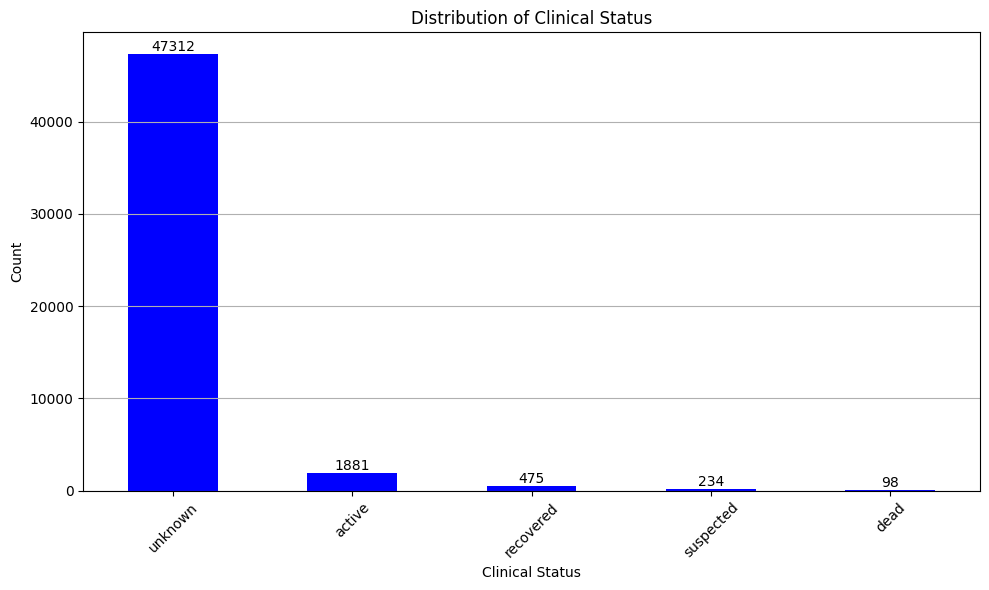

In [86]:
df2["clinical_status"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Clinical Status')
plt.ylabel('Count')
plt.title('Distribution of Clinical Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

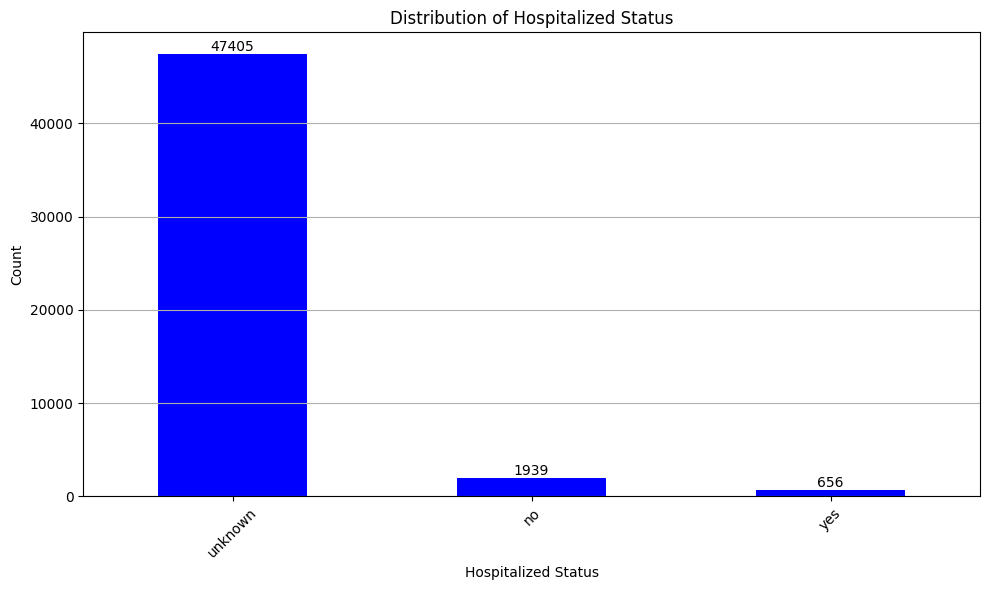

In [87]:
df2["hospitalized"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Hospitalized Status')
plt.ylabel('Count')
plt.title('Distribution of Hospitalized Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

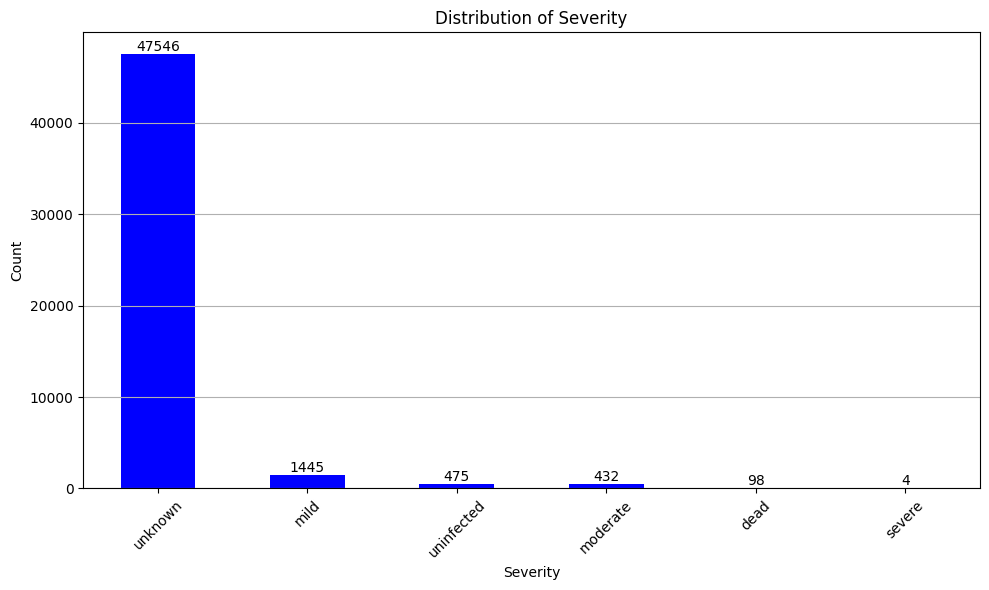

In [88]:
df2["severity"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Severity')
plt.ylabel('Count')
plt.title('Distribution of Severity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [89]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Accession ID     50000 non-null  object
 1   Gender           50000 non-null  object
 2   Patient age      49999 non-null  object
 3   Patient status   50000 non-null  object
 4   continent        50000 non-null  object
 5   country          50000 non-null  object
 6   state            46741 non-null  object
 7   city             14820 non-null  object
 8   clinical_status  50000 non-null  object
 9   hospitalized     50000 non-null  object
 10  severity         50000 non-null  object
dtypes: object(11)
memory usage: 4.2+ MB


Let's first see how healthy each country is in terms of `clinical_status`

In [90]:
score_map = {"unknown": 0, "recovered": 1, "suspected": 2, "active": 3, "dead": 4}

In [91]:
df2["clinical_status_score"] = df2['clinical_status'].map(score_map)
df2["clinical_status_score"].describe()

count    50000.000000
mean         0.139560
std          0.615378
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: clinical_status_score, dtype: float64

In [92]:
df_merged["clinical_status_per_lakh"] = float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "clinical_status_per_lakh"] = (df2[(df2["country"] == country)]["clinical_status_score"].mean())/(row[f"population_{YEAR}"] / 1e5)
df_merged["clinical_status_per_lakh"].describe()

count    150.000000
mean       0.079446
std        0.674565
min        0.000000
25%        0.000000
50%        0.000000
75%        0.003602
max        8.146861
Name: clinical_status_per_lakh, dtype: float64

In [93]:
df_merged["log_clinical_status_per_lakh"] = np.log10(df_merged["clinical_status_per_lakh"].replace(0, np.nan))
df_merged["log_clinical_status_per_lakh"].describe()

count    73.000000
mean     -2.480216
std       1.316233
min      -5.423506
25%      -3.086272
50%      -2.390237
75%      -1.571948
max       0.910990
Name: log_clinical_status_per_lakh, dtype: float64

In [94]:
sign = -1 if df_merged["log_clinical_status_per_lakh"].min() < 0 else 1
df_merged["log_clinical_status_per_lakh"] = df_merged["log_clinical_status_per_lakh"] + (df_merged["log_clinical_status_per_lakh"].min() * sign)
df_merged["log_clinical_status_per_lakh"].describe()

count    73.000000
mean      2.943290
std       1.316233
min       0.000000
25%       2.337234
50%       3.033269
75%       3.851558
max       6.334497
Name: log_clinical_status_per_lakh, dtype: float64

In [95]:
df_merged = col_fillna(df_merged, "log_clinical_status_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],     # NaN or missing → light grey
    [0.0001, "#1a9850"],  # green
    [0.25,   "#a6d96a"],  # light green
    [0.5,    "#ffffbf"],  # yellow
    [0.75,   "#fdae61"],  # orange
    [1.0,    "#a50026"]   # red
]


fig = choropleth_world(df_merged,
                       value_column="log_clinical_status_per_lakh",
                       color_scale=custom_scale,
                       title=f"Clinical status (World) | Log 10 Scale | {YEAR}",
                       label="Avg clinical status/1 Lakh",
                       hover_data={
                            'clinical_status_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_clinical_status_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [96]:
fig = choropleth_continent(df_merged,
                           value_column='log_clinical_status_per_lakh',
                           color_scale=custom_scale,
                           title=f"Health status (continents) | Log 10 Scale | {YEAR}",
                           label="Avg clinical status/1 Lakh (Log 10)",
                            hover_data={"clinical_status_per_lakh": True,
                                        f"population_{YEAR}": True,
                                        "country": False},
                            YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_clinical_status_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see the hospitalization status and later we can see how well-equiped the hospitals in each country are

In [97]:
fig = plot_dominant_choropleth(
        df2,
        value_column='hospitalized',
        color_map={
            'yes': '#1a9850',   # blue
            'no': "#a50026",   # pink,
            'unknown':'#bdbdbd'  # gray for unknown
        },
        title="Majority hospitalized status",
        year=YEAR
    )
fig.show()

In [98]:
df_merged.columns

Index(['country', 'continent', 'population_2021', 'country_standard',
       'num_entries', 'num_entries_per_lakh', 'log_num_entries_per_lakh',
       'log_num_entries_per_lakh_filled', 'sex_m_per_lakh', 'sex_f_per_lakh',
       'sex_u_per_lakh', 'log_sex_m_per_lakh', 'log_sex_m_per_lakh_filled',
       'log_sex_f_per_lakh', 'log_sex_f_per_lakh_filled', 'log_sex_u_per_lakh',
       'log_sex_u_per_lakh_filled', 'male_female_ratio',
       'male_female_ratio_filled', 'clinical_status_per_lakh',
       'log_clinical_status_per_lakh', 'log_clinical_status_per_lakh_filled'],
      dtype='object')

### A.4. Age distribution

Let's see what is the age distribution of the patients across each geographical location

In [99]:
df2["Patient age"].unique()

array(['70', '67', '37', 'unknown', '44', '53', '73', '32', '78', '54',
       '56', '45', '47', '22', '90', '84', '82', '19', '48', '20', '58',
       '55-58', '43-46', '29', '11', '41', '40', '6', '24', '27', '42',
       '65', '26', '0 - 18', '57', '39', '4', '52', '89', '14', '1', '21',
       '38', '55', '10', '30', '64', '71', '50', '13', '49', '79', '35',
       '86', '16', '33', '83', '81', '12', '25', '68', '69', '49-52',
       '17', '36.0', '80', '23', '60', '36', 'unkown', '0', '94', '28',
       '63', '31', '76', '59', '93', '2', '3', '75', '92', '74', '31-40',
       '91', '11-20', '34', '66', '21-30', '61', '51', '>18', nan, '62',
       '43', '46', '5', '72', '8', '<16', '77', 'Unknown', '81-90',
       '51-60', '85+', '41-50', '85', '41.0', '84.0', '88', '76.0', '95',
       '15', '98', '87', '7', '9', '70-79', '40-43', '70-73', '11 months',
       '12 days', '6 months', '18', '4 months', '22-25', '52-55', '37-40',
       '28-31', '25-28', '1.33', '73-76', '96', '9 mon

The age format reported here is very varied and requires to be standardized. We refer the age brackets and the classification provided by the [Global Burden of Diseases](https://ourworldindata.org/burden-of-disease):

- `< 5` years old
- `5-14` years old
- `15-49` years old
- `50-69` years old
- `> 70` years old

In [100]:
df2['age_group'] = df2['Patient age'].apply(map_age_to_group)

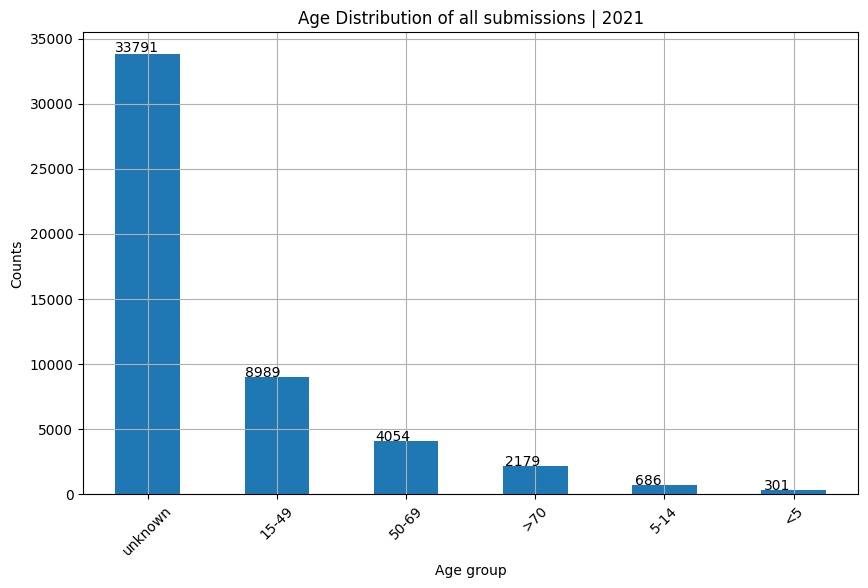

In [101]:
# Plot the bar chart
ax = df2["age_group"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Age group')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title(f'Age Distribution of all submissions | {YEAR}')
plt.show()

In [102]:
import plotly.express as px

df_grouped = df2.groupby(["country", "age_group"]).size().reset_index(name="count")

df_grouped

,country,age_group,count
0,Albania,15-49,2
1,Albania,50-69,1
2,Algeria,15-49,2
3,Algeria,5-14,1
4,Algeria,50-69,1
...,...,...,...
459,Zimbabwe,15-49,74
460,Zimbabwe,5-14,2
461,Zimbabwe,50-69,15
462,Zimbabwe,<5,1


In [103]:
fig = px.choropleth(
    df_grouped,
    locations="country",
    color="count",
    locationmode="country names",
    animation_frame="age_group",
    color_continuous_scale="YlGnBu",
    title=f"Age Group-wise Entries by Country | {YEAR}"
)
# Adjust the order of labels in the slider
# Desired order: '<5', '5-14', '15-49', '50-69', '>70', 'unknown'
desired_order = ['<5', '5-14', '15-49', '50-69', '>70', 'unknown']

# Find the current order of frames
current_order = [frame.name for frame in fig.frames]

# Create a mapping from label to frame
frame_dict = {frame.name: frame for frame in fig.frames}

# Reorder frames
fig.frames = tuple([frame_dict[label] for label in desired_order if label in frame_dict])

# Update slider steps order
for slider in fig.layout.sliders:
    step_dict = {step['label']: step for step in slider['steps']}
    slider['steps'] = [step_dict[label] for label in desired_order if label in step_dict]

fig.update_layout(title_x=0.5, width=1200, height=700)

fig.show()

In [104]:
fig = plot_dominant_choropleth(
    df2,
    value_column='age_group',
    color_map={
        '<5': '#e5f5e0',      # light green
        '5-14': '#a1d99b',
        '15-49': '#41ab5d',   # more contrast
        '50-69': '#238b45',   # more contrast
        '>70': '#005824',     # darkest green for high contrast
        'unknown': '#bdbdbd'  # gray for unknown
    },
    title="Dominant Age Group (Green Shades)",
    year=YEAR
    )
fig.show()

In [105]:
df_merged.groupby("continent").agg({"num_entries_per_lakh":"mean","sex_m_per_lakh":"mean","sex_f_per_lakh":"mean",
                                    "sex_u_per_lakh":"mean","male_female_ratio":"mean", "clinical_status_per_lakh":"mean"})

,num_entries_per_lakh,sex_m_per_lakh,sex_f_per_lakh,sex_u_per_lakh,male_female_ratio,clinical_status_per_lakh
continent,,,,,,
Africa,0.925817,0.254732,0.531357,0.139728,1.291133,0.050243
Antarctica,NaN,NaN,NaN,NaN,NaN,NaN
Asia,0.527387,0.079774,0.081973,0.365640,1.187608,0.007930
Europe,8.557218,3.410293,3.616085,1.530840,1.011280,0.215260
North America,3.504911,0.300893,1.542508,1.661511,0.648615,0.017908
Oceania,1.286343,0.171644,0.366976,0.747723,1.141176,0.000000
South America,0.498527,0.042535,0.041633,0.414359,1.109021,0.073927
